# Robustness Analysis

This notebook documents the robustness analysis for the first FRB isotropy paper. The heavy, reproducible execution lives in `scripts/run_robustness_analysis.py`; this notebook is the paper-facing inspection layer for the aggregated summary, supplementary table, robustness criterion, and figures.

Default workflow:

1. Run the robustness driver from the terminal, or use the optional cell below.
2. Load `outputs/robustness_summary.csv`.
3. Regenerate and inspect the paper products in `outputs/robustness/`.

In [5]:
from __future__ import annotations

import subprocess
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PYTHON = Path(sys.executable)
SCRIPT = PROJECT_ROOT / "scripts" / "run_robustness_analysis.py"
SUMMARY_CSV = PROJECT_ROOT / "outputs" / "robustness" / "robustness_summary.csv"
ROBUSTNESS_DIR = PROJECT_ROOT / "outputs" / "robustness"
FIGURES_DIR = ROBUSTNESS_DIR / "figures"
TABLES_DIR = ROBUSTNESS_DIR / "tables"

PROJECT_ROOT, PYTHON


(PosixPath('/home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy'),
 PosixPath('/home/brunowesley/projetos/venv/bin/python'))

## Run the full robustness sweep if needed

This is the long step. By default, this notebook runs the full robustness sweep automatically when outputs/robustness_summary.csv is missing. Set RUN_FULL_SWEEP_IF_MISSING = False if you only want to inspect already-generated products.


In [2]:
RUN_FULL_SWEEP_IF_MISSING = True

if SUMMARY_CSV.exists():
    print(f"Found {SUMMARY_CSV}")
elif RUN_FULL_SWEEP_IF_MISSING:
    print("Robustness summary not found. Running the full robustness sweep now.")
    subprocess.run([
        str(PYTHON),
        str(SCRIPT),
    ], cwd=PROJECT_ROOT, check=True)
else:
    print("Robustness summary not found.")
    print("Run the full sweep before the plots-only cell. Terminal command:")
    print(f"cd {PROJECT_ROOT}")
    print(f"{PYTHON} scripts/run_robustness_analysis.py")


Robustness summary not found. Running the full robustness sweep now.
Planned robustness runs: 22
001 fiducial           fiducial                 robustness_fiducial_mask_sf_gal20_bin10_nside32_smooth3
002 oat_mask_sf        gal_cut                  robustness_oat_gal_cut_15_mask_sf_gal15_bin10_nside32_smooth3
003 oat_mask_sf        gal_cut                  robustness_oat_gal_cut_20_mask_sf_gal20_bin10_nside32_smooth3
004 oat_mask_sf        gal_cut                  robustness_oat_gal_cut_25_mask_sf_gal25_bin10_nside32_smooth3
005 oat_mask_sf        smooth_sigma             robustness_oat_smooth_sigma_1_mask_sf_gal20_bin10_nside32_smooth1
006 oat_mask_sf        smooth_sigma             robustness_oat_smooth_sigma_3_mask_sf_gal20_bin10_nside32_smooth3
007 oat_mask_sf        smooth_sigma             robustness_oat_smooth_sigma_5_mask_sf_gal20_bin10_nside32_smooth5
008 oat_mask_sf        nside_sf                 robustness_oat_nside_sf_16_mask_sf_gal20_bin10_nside16_smooth3
009 oat_mask_sf 

## Regenerate paper products from the summary CSV

This is lightweight compared with the full sweep. It recreates the supplementary tables, the OAT sensitivity plot, the smooth_sigma x nside_sf heatmap, and the predefined robustness-criterion summary.


In [6]:
if not SUMMARY_CSV.exists():
    raise RuntimeError(
        "Missing robustness_summary.csv. Run the previous cell with "
        "RUN_FULL_SWEEP_IF_MISSING = True, or run scripts/run_robustness_analysis.py "
        "from the project root."
    )

subprocess.run([
    str(PYTHON),
    str(SCRIPT),
    "--plots-only",
], cwd=PROJECT_ROOT, check=True)


Saved robustness paper products: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/outputs/robustness


CompletedProcess(args=['/home/brunowesley/projetos/venv/bin/python', '/home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/scripts/run_robustness_analysis.py', '--plots-only'], returncode=0)

## Load aggregated results

In [7]:
summary = pd.read_csv(SUMMARY_CSV)
summary.shape, summary["status"].value_counts(dropna=False).to_dict()

((22, 40), {'success': 22})

In [8]:
failed = summary.loc[summary["status"].eq("failed")]
failed[["sweep", "parameter", "value", "run_tag", "error_type", "error_message"]]

,sweep,parameter,value,run_tag,error_type,error_message


## Predefined robustness criterion

The criterion is evaluated before interpreting the result: the qualitative rejection status must remain unchanged across the tested mask+SF runs, and the SVD-equivalent tension must remain inside the chosen stability band around the fiducial value.

In [9]:
criterion = pd.read_csv(TABLES_DIR / "robustness_criterion_summary.csv")
criterion

,fiducial_sigma_svd_equiv,rejection_sigma,stability_band,max_abs_delta_sigma,fiducial_rejects_isotropy,qualitative_status_stable,within_stability_band,robust_by_predefined_criterion,n_successful_paper_runs,n_unique_physical_configs,n_failed_runs
0,-0.807149,3.0,0.5,2.904483,False,True,False,False,22,13,0


## Supplementary table

In [10]:
supplementary = pd.read_csv(TABLES_DIR / "robustness_supplementary_table.csv")
columns = [
    "sweep",
    "parameter",
    "value",
    "gal_cut",
    "smooth_sigma",
    "nside_sf",
    "bin_size",
    "svd_sigma_svd_equiv",
    "svd_p_svd_empirical",
    "chi2_sigma_equiv",
    "chi2_p_empirical",
    "ks_w_empirical_p",
    "ad_w_empirical_p",
    "absolute_global_tension",
    "covariance_condition",
    "n_eff",
]
supplementary[[column for column in columns if column in supplementary.columns]]

,sweep,parameter,value,gal_cut,smooth_sigma,nside_sf,bin_size,svd_sigma_svd_equiv,svd_p_svd_empirical,chi2_sigma_equiv,chi2_p_empirical,ks_w_empirical_p,ad_w_empirical_p,absolute_global_tension,covariance_condition,n_eff
0,fiducial,fiducial,fiducial,20.0,3.0,32,10.0,-0.807149,0.790210,-0.803686,0.789211,0.012987,0.011988,1.700070,956.712914,4.643951
1,oat_mask_sf,gal_cut,15.0,15.0,3.0,32,10.0,0.650322,0.257742,0.656522,0.255744,0.320679,0.101898,0.568074,902.493231,4.765796
2,oat_mask_sf,gal_cut,20.0,20.0,3.0,32,10.0,-0.807149,0.790210,-0.803686,0.789211,0.012987,0.011988,1.700070,956.712914,4.643951
3,oat_mask_sf,gal_cut,25.0,25.0,3.0,32,10.0,-1.045690,0.852148,-1.045690,0.852148,0.108891,0.096903,1.071229,640.115766,5.291481
4,oat_mask_sf,smooth_sigma,1.0,20.0,1.0,32,10.0,-0.083987,0.533467,-0.073939,0.529471,0.404595,0.426573,1.782022,972.982085,4.511264
5,oat_mask_sf,smooth_sigma,3.0,20.0,3.0,32,10.0,-0.807149,0.790210,-0.803686,0.789211,0.012987,0.011988,1.700070,956.712914,4.643951
6,oat_mask_sf,smooth_sigma,5.0,20.0,5.0,32,10.0,1.276445,0.100899,1.293598,0.097902,0.101898,0.084915,0.464139,882.897216,4.824017
7,oat_mask_sf,nside_sf,16,20.0,3.0,16,10.0,-0.346096,0.635365,-0.346096,0.635365,0.092907,0.011988,1.146486,957.433983,4.673802
8,oat_mask_sf,nside_sf,32,20.0,3.0,32,10.0,-0.807149,0.790210,-0.803686,0.789211,0.012987,0.011988,1.700070,956.712914,4.643951
9,oat_mask_sf,nside_sf,64,20.0,3.0,64,10.0,-0.429812,0.666334,-0.421587,0.663337,0.848152,0.989011,1.403992,826.746231,5.011857


## OAT sensitivity figure

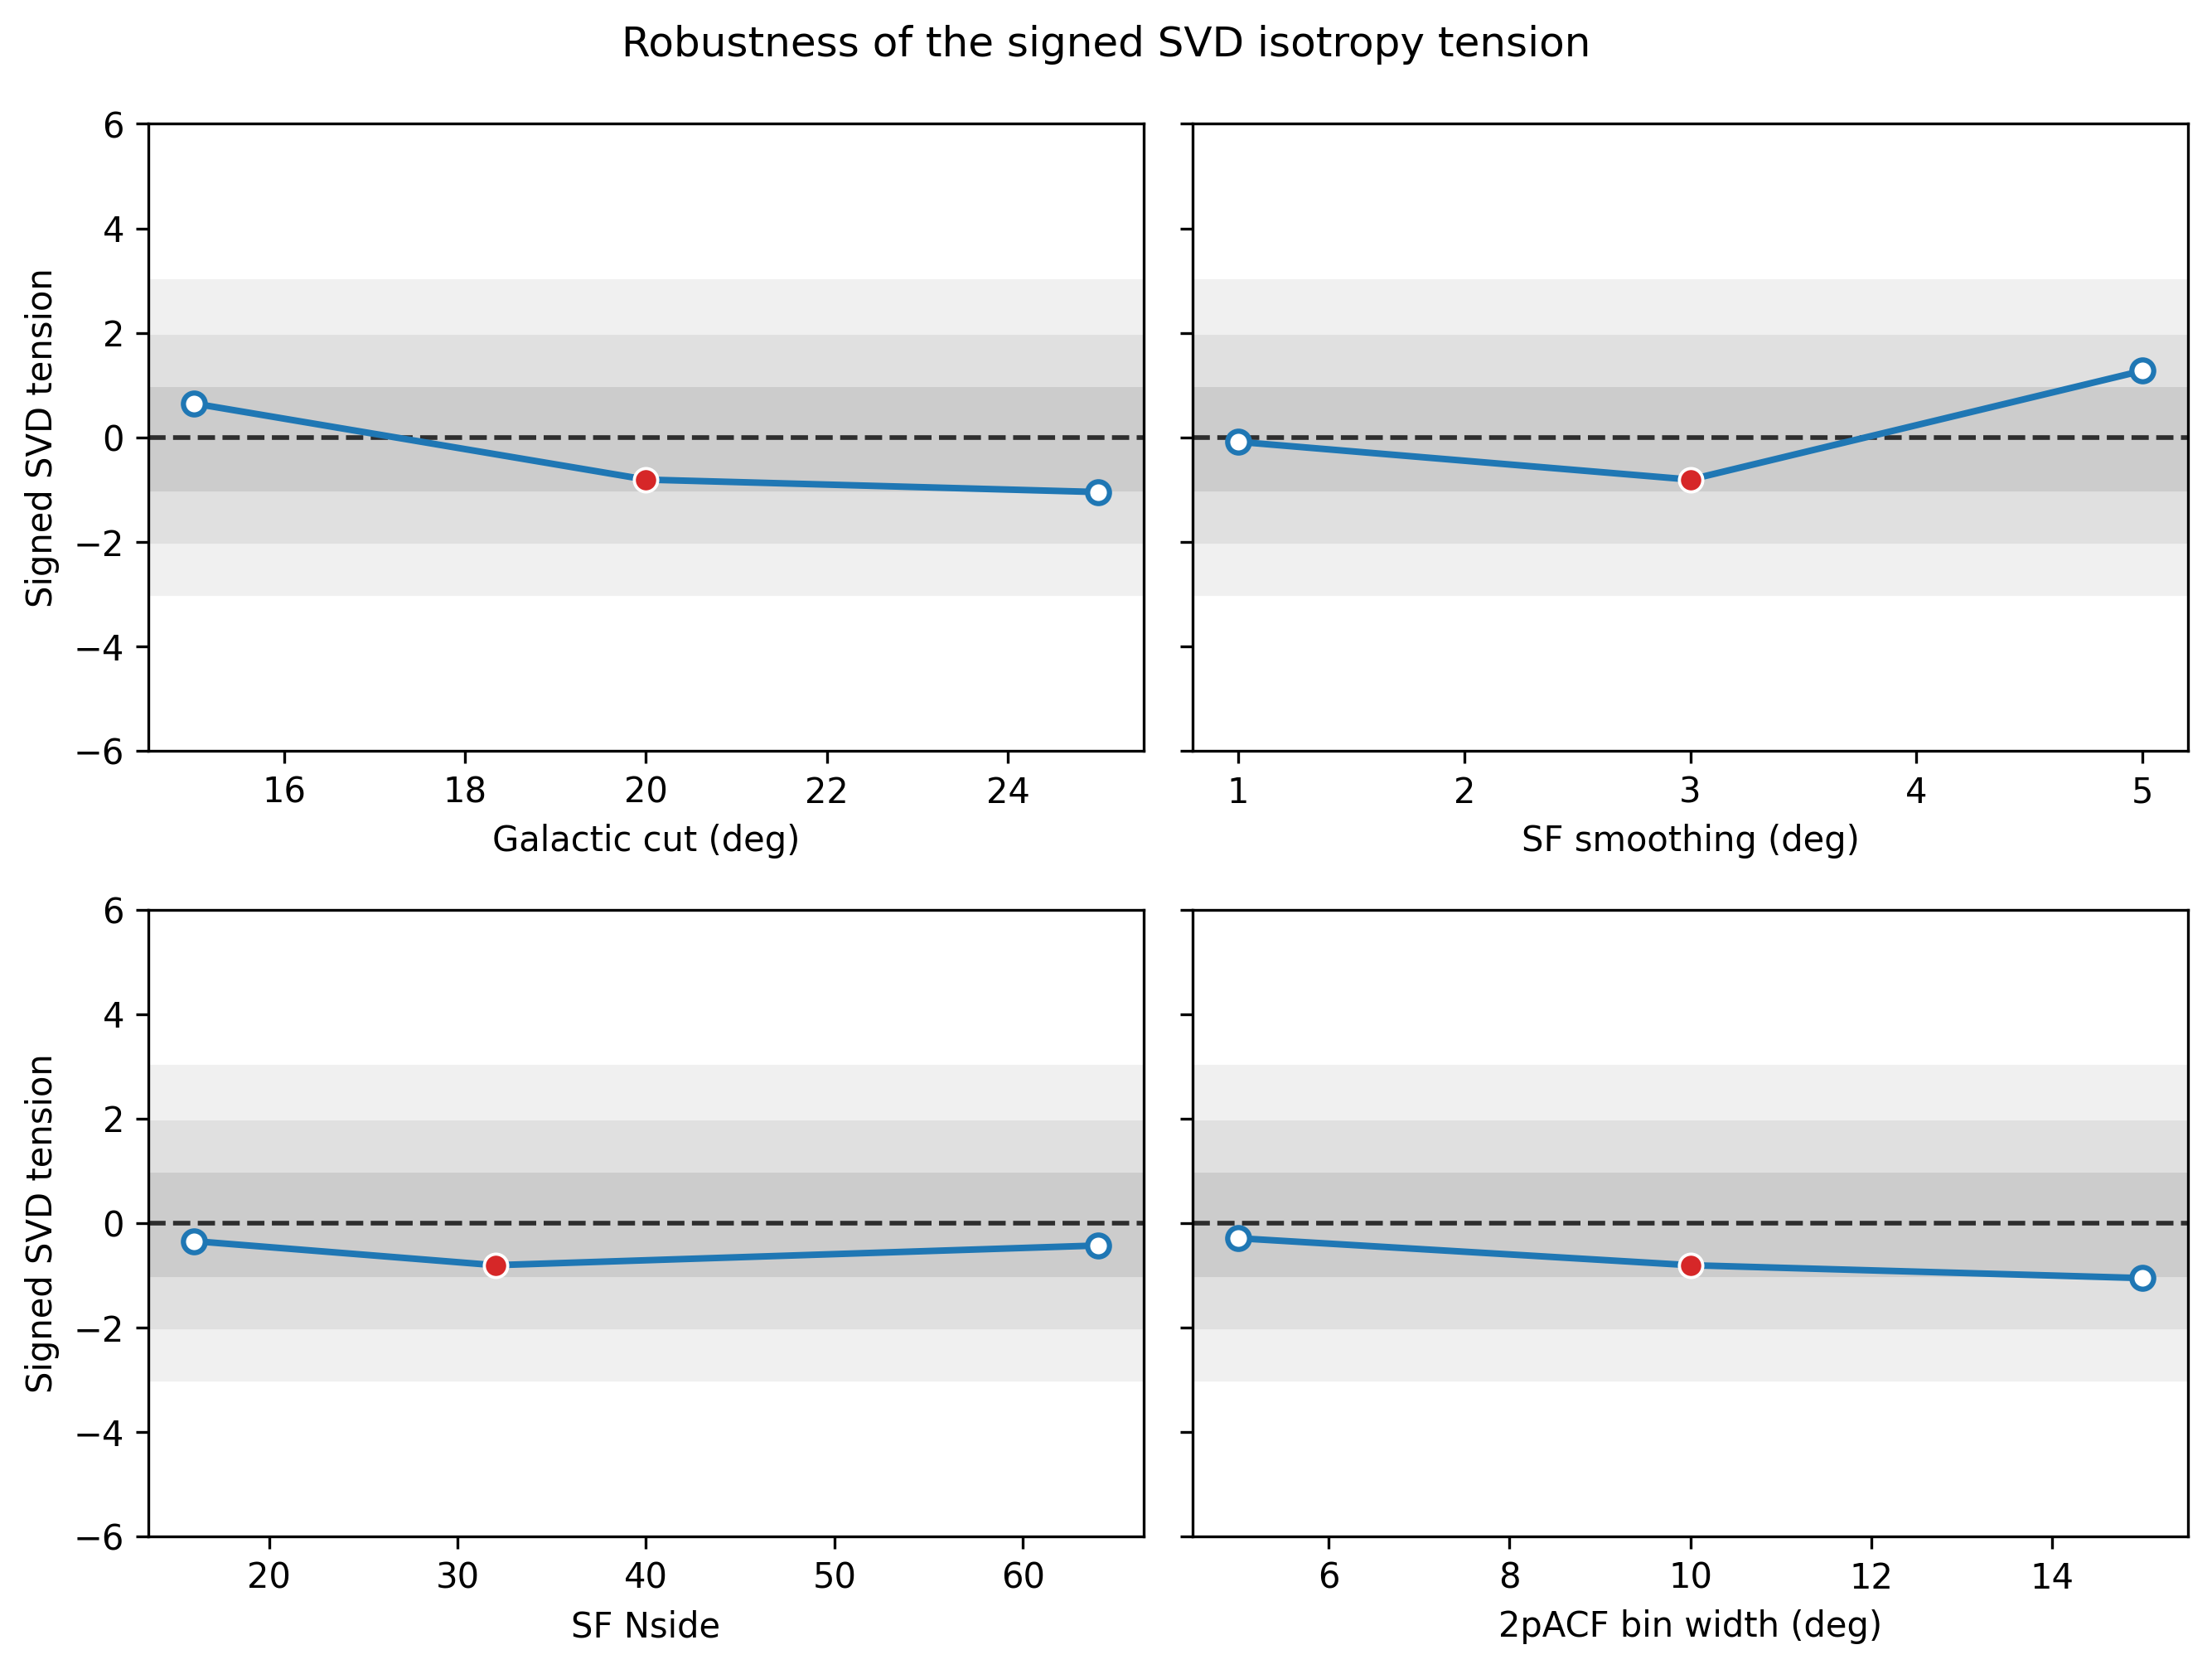

In [11]:
display(Image(filename=FIGURES_DIR / "robustness_sensitivity_oat.png"))

## Selection-function smoothness/resolution heatmap

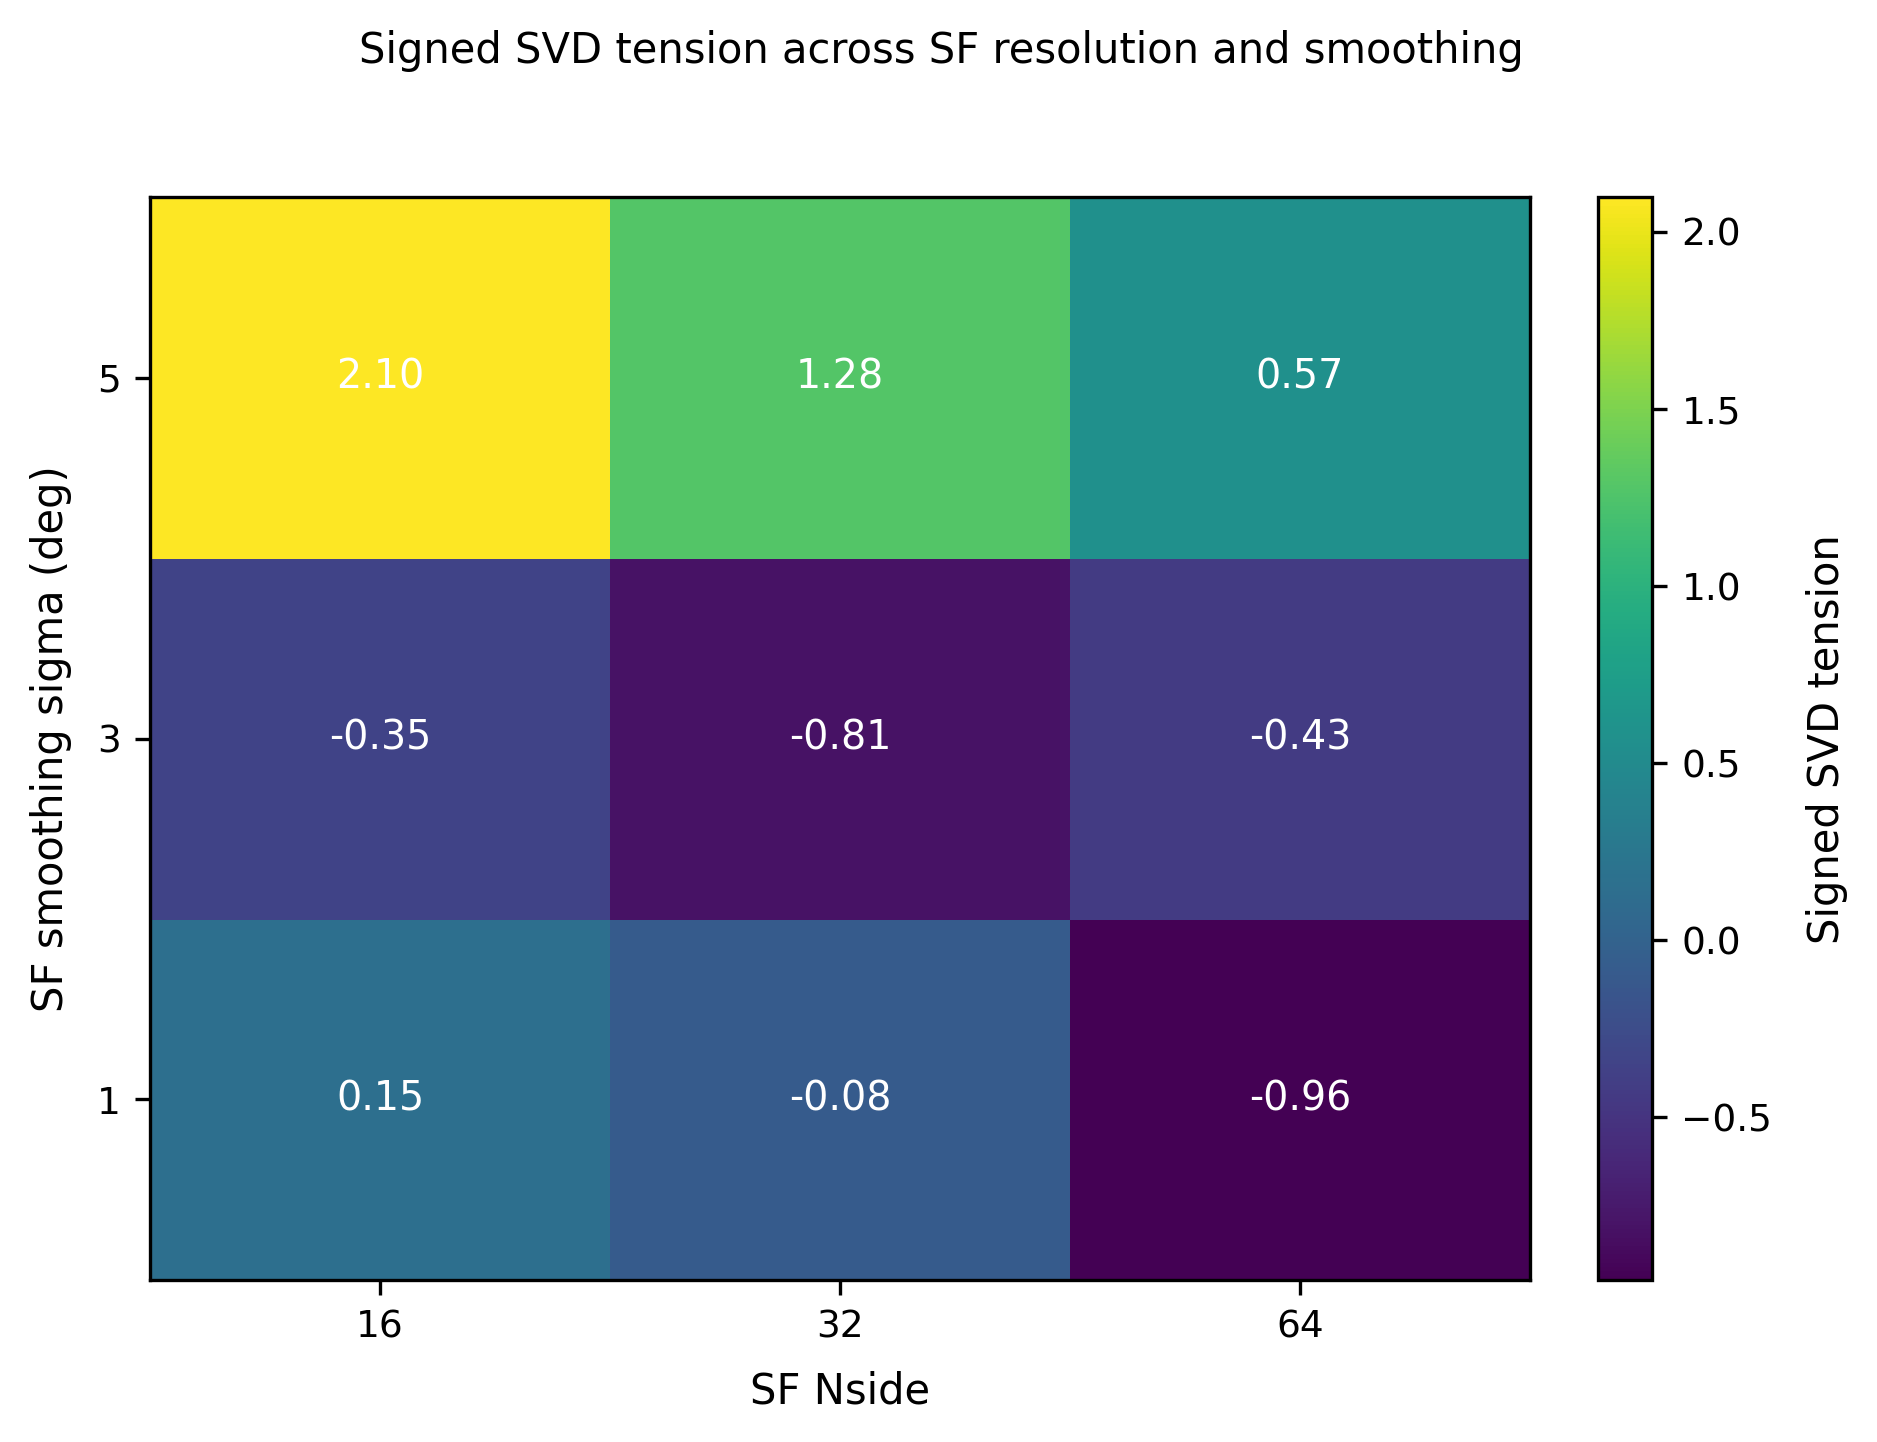

In [12]:
display(Image(filename=FIGURES_DIR / "robustness_smooth_nside_heatmap.png"))

## OAT numerical view

In [13]:
oat = summary.loc[
    summary["status"].eq("success")
    & summary["sweep"].eq("oat_mask_sf")
].copy()

oat[[
    "parameter",
    "value",
    "svd_sigma_svd_equiv",
    "chi2_sigma_equiv",
    "svd_p_svd_empirical",
    "covariance_condition",
    "n_eff",
]].sort_values(["parameter", "value"])

,parameter,value,svd_sigma_svd_equiv,chi2_sigma_equiv,svd_p_svd_empirical,covariance_condition,n_eff
11,bin_size,10.0,-0.807149,-0.803686,0.790210,956.712914,4.643951
12,bin_size,15.0,-1.054381,-1.007517,0.854146,764.858450,3.776990
10,bin_size,5.0,-0.290768,-0.280335,0.614386,1358.124809,6.513396
1,gal_cut,15.0,0.650322,0.656522,0.257742,902.493231,4.765796
2,gal_cut,20.0,-0.807149,-0.803686,0.790210,956.712914,4.643951
3,gal_cut,25.0,-1.045690,-1.045690,0.852148,640.115766,5.291481
7,nside_sf,16,-0.346096,-0.346096,0.635365,957.433983,4.673802
8,nside_sf,32,-0.807149,-0.803686,0.790210,956.712914,4.643951
9,nside_sf,64,-0.429812,-0.421587,0.666334,826.746231,5.011857
4,smooth_sigma,1.0,-0.083987,-0.073939,0.533467,972.982085,4.511264


## `smooth_sigma x nside_sf` numerical view

In [14]:
grid = summary.loc[
    summary["status"].eq("success")
    & summary["sweep"].eq("smooth_nside_grid")
].copy()

grid.pivot_table(
    index="smooth_sigma",
    columns="nside_sf",
    values="svd_sigma_svd_equiv",
    aggfunc="mean",
).sort_index().sort_index(axis=1)

nside_sf,16,32,64
smooth_sigma,,,
1.0,0.152084,-0.083987,-0.958794
3.0,-0.346096,-0.807149,-0.429812
5.0,2.097334,1.276445,0.574788


## Paper notes

For the first paper, this notebook complements the main isotropy notebook. The CHIME empirical/instrumental SF comparison and controlled SF injection/recovery notebooks are kept as second-paper material.

Suggested text to adapt in the methods section: all robustness runs use common random numbers by keeping the explicit random seeds fixed across the sweep, so changes in the reported tension mainly reflect the tested analysis choice rather than Monte Carlo noise.